<a href="https://colab.research.google.com/github/Bootcamp-DA-P3/Proyecto3_Flujo-SQL-PY-DRR/blob/main/notebooks/Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("¡Librerías importadas con éxito! Listo para trabajar con los datos.")

¡Librerías importadas con éxito! Listo para trabajar con los datos.


LECTURA DEL PRIMER DATAFRAME

In [6]:
# Cargamos el dataset omitiendo las líneas que causan error de formato (por ejemplo, comas adicionales mal escapadas)
df = pd.read_csv('/content/drive/MyDrive/Proyecto3_Flujo-SQL-PY-DRR/Data/actividad_de_clientes_limpio.csv', on_bad_lines='skip')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   customer_id                    1000 non-null   object 
 1   customer_unique_id             1000 non-null   object 
 2   customer_zip_code_prefix       1000 non-null   int64  
 3   customer_city                  1000 non-null   object 
 4   customer_state                 1000 non-null   object 
 5   order_id                       1000 non-null   object 
 6   order_status                   1000 non-null   object 
 7   order_purchase_timestamp       1000 non-null   object 
 8   order_approved_at              1000 non-null   object 
 9   order_delivered_carrier_date   1000 non-null   object 
 10  order_delivered_customer_date  1000 non-null   object 
 11  order_estimated_delivery_date  1000 non-null   object 
 12  delivery_days                  1000 non-null   in

In [7]:
# 1. Convertir fechas a datetime
date_columns = [
    'order_purchase_timestamp', 'order_approved_at',
    'order_delivered_carrier_date', 'order_delivered_customer_date',
    'order_estimated_delivery_date', 'review_creation_date',
    'review_answer_timestamp'
]
for col in date_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

In [8]:
# Comprobamos si hay filas duplicadas
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

Número de filas duplicadas: 0


In [9]:
# Eliminamos las filas duplicadas
df = df.drop_duplicates()

# Comprobamos cuántas filas nos quedan ahora
print(f"Número de filas después de limpiar duplicados: {len(df)}")

Número de filas después de limpiar duplicados: 998


In [10]:
# 3. Analizar valores faltantes
missing = df.isnull().sum()
print("\nValores faltantes por columna:")
print(missing[missing > 0])


Valores faltantes por columna:
review_id                   10
review_score                10
review_comment_title       878
review_comment_message     574
review_creation_date        10
review_answer_timestamp     10
geolocation_lat              3
geolocation_lng              3
geo_city                     3
geo_state                    3
dtype: int64


In [11]:
# Documentación / Tratamiento: los comentarios nulos se rellenan con cadena vacía o indicador
df['review_comment_title'] = df['review_comment_title'].fillna('Sin título')
df['review_comment_message'] = df['review_comment_message'].fillna('Sin mensaje')

In [12]:
# 3. Comprobamos los valores faltantes
missing = df.isnull().sum()
print("\nValores faltantes por columna:")
print(missing[missing > 0])


Valores faltantes por columna:
review_id                  10
review_score               10
review_creation_date       10
review_answer_timestamp    10
geolocation_lat             3
geolocation_lng             3
geo_city                    3
geo_state                   3
dtype: int64


In [13]:
# 4. Normalizar cadenas (lower, trim)
str_columns = df.select_dtypes(include=['object', 'string']).columns
for col in str_columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [16]:
# 5. Corregir tipos numéricos de manera segura
df['customer_zip_code_prefix'] = df['customer_zip_code_prefix'].astype(str)

# Convertimos a numérico primero para evitar problemas de casteo directo desde strings con decimales o nulos
review_score_numeric = pd.to_numeric(df['review_score'], errors='coerce')
df['review_score'] = review_score_numeric.round().astype('Int64')

payment_installments_numeric = pd.to_numeric(df['payment_installments'], errors='coerce')
df['payment_installments'] = payment_installments_numeric.round().astype('Int64')

df['payment_value'] = pd.to_numeric(df['payment_value'], errors='coerce')

In [19]:
# 6. Detectar outliers (Ejemplo con IQR en payment_value)
Q1 = df['payment_value'].quantile(0.25)
Q3 = df['payment_value'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['payment_value'] < (Q1 - 1.5 * IQR)) | (df['payment_value'] > (Q3 + 1.5 * IQR))]
print(f"\nNúmero de outliers detectados en payment_value: {len(outliers)}")


Número de outliers detectados en payment_value: 76


In [20]:
# 7. Crear columnas derivadas útiles
# Ejemplo: Tiempo real de entrega en días y diferencia con la estimación
if 'order_delivered_customer_date' in df.columns and 'order_purchase_timestamp' in df.columns:
    df['delivery_time_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

if 'order_estimated_delivery_date' in df.columns and 'order_delivered_customer_date' in df.columns:
    df['delay_vs_estimated_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.total_seconds() / (24 * 3600)

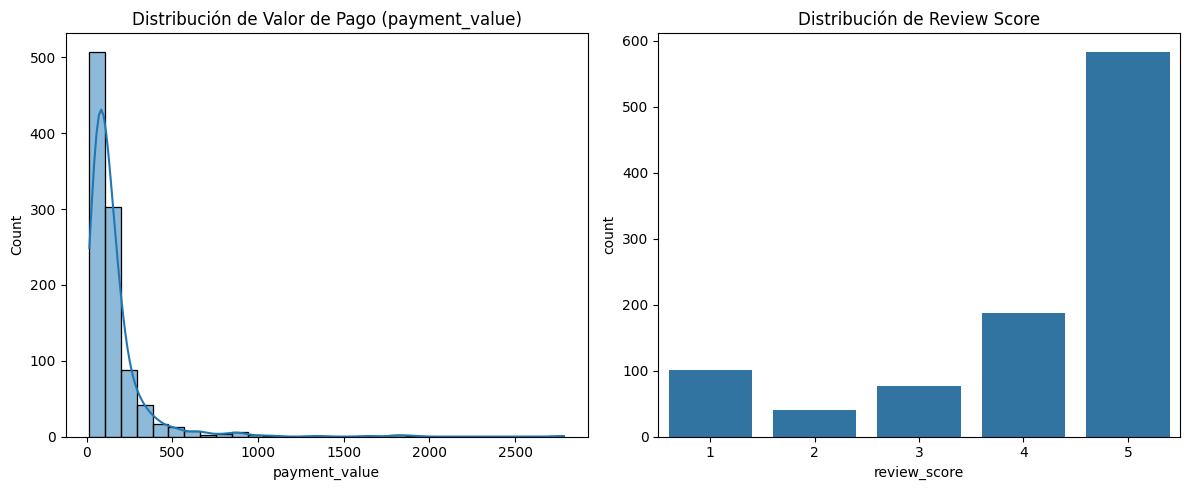

In [21]:
# 8. Generar visualizaciones para validar la distribución de datos
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['payment_value'], bins=30, kde=True)
plt.title('Distribución de Valor de Pago (payment_value)')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='review_score')
plt.title('Distribución de Review Score')

plt.tight_layout()
plt.show()

In [22]:
# Resumen estadístico de las columnas numéricas
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,is_late,payment_sequential,payment_installments,payment_value,review_score,review_creation_date,review_answer_timestamp,geolocation_lat,geolocation_lng,delivery_time_days,delay_vs_estimated_days
count,998,998,998,998,998,998.000000,998.000000,998.000000,998.0,998.000000,988.0,988,988,995.000000,995.000000,998.000000,998.000000
mean,2018-01-01 16:24:54.974949632,2018-01-02 02:22:48.329659392,2018-01-04 23:42:17.964929792,2018-01-14 06:11:06.721442816,2018-01-25 02:08:25.010020096,12.506012,0.082164,1.001002,2.96994,153.150611,4.125506,2018-01-15 03:34:18.704453632,2018-01-18 12:43:03.657894912,-21.331316,-46.284898,12.573747,-10.831462
min,2016-10-07 10:52:22,2016-10-07 18:01:40,2016-10-21 12:47:02,2016-10-27 09:37:52,2016-11-29 00:00:00,1.000000,0.000000,1.000000,1.0,15.570000,1.0,2016-10-31 00:00:00,2016-11-02 12:04:41,-31.327268,-63.040234,1.114595,-55.357766
25%,2017-09-15 15:34:39.500000,2017-09-15 19:23:39,2017-09-19 02:17:26,2017-09-27 12:16:10,2017-10-04 00:00:00,7.000000,0.000000,1.000000,1.0,61.732500,4.0,2017-09-28 00:00:00,2017-10-03 23:00:21.750000128,-23.602216,-47.955339,6.689253,-16.116461
50%,2018-01-21 04:28:20,2018-01-21 17:44:30.500000,2018-01-23 23:03:18.500000,2018-02-02 20:50:16,2018-02-16 00:00:00,10.000000,0.000000,1.000000,2.0,105.470000,5.0,2018-02-05 00:00:00,2018-02-07 06:02:48,-22.928999,-46.632926,9.985440,-11.411753
75%,2018-04-30 23:38:09,2018-05-02 05:13:37,2018-05-03 16:15:00,2018-05-10 20:30:44.500000,2018-05-22 00:00:00,16.000000,0.000000,1.000000,4.0,169.975000,5.0,2018-05-11 00:00:00,2018-05-15 01:21:50.249999872,-20.328022,-43.921642,15.725547,-6.289167
max,2018-08-28 21:10:46,2018-08-28 21:25:15,2018-08-29 13:24:00,2018-09-17 14:42:46,2018-09-26 00:00:00,96.000000,1.000000,2.000000,15.0,2784.160000,5.0,2018-08-31 00:00:00,2018-10-16 14:57:27,0.055709,-34.830257,96.312894,74.779468
std,NaN,NaN,NaN,NaN,NaN,9.709081,0.274753,0.031654,2.746585,195.176734,1.317191,NaN,NaN,5.375258,3.840209,9.709654,10.352693


In [26]:
# 9. Exportar dataset final (sin subir al repo / añadir al .gitignore)
df.to_csv('/content/drive/MyDrive/Proyecto3_Flujo-SQL-PY-DRR/Data/actividad_de_clientes_procesado.csv', index=False)

LECTURA DEL SEGUNDO DATAFRAME

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Proyecto3_Flujo-SQL-PY-DRR/Data/catalogo_limpio.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1000 non-null   object 
 1   categoria_original   1000 non-null   object 
 2   categoria_traducida  1000 non-null   object 
 3   price                1000 non-null   float64
 4   freight_value        1000 non-null   float64
 5   seller_id            1000 non-null   object 
 6   product_weight_g     1000 non-null   int64  
 7   is_heavy             1000 non-null   int64  
 8   freight_ratio        1000 non-null   float64
dtypes: float64(3), int64(2), object(4)
memory usage: 70.4+ KB


In [ ]:
# Comprobamos si hay filas duplicadas
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

Número de filas duplicadas: 100


In [ ]:
# Eliminamos las filas duplicadas
df = df.drop_duplicates()

# Comprobamos cuántas filas nos quedan ahora
print(f"Número de filas después de limpiar duplicados: {len(df)}")

Número de filas después de limpiar duplicados: 900


In [ ]:
# Normalizamos las columnas de texto (quitamos espacios y dejamos en minúsculas por si acaso)
df['categoria_original'] = df['categoria_original'].astype(str).str.strip().str.lower()
df['categoria_traducida'] = df['categoria_traducida'].astype(str).str.strip().str.lower()

print("¡Cadenas de texto normalizadas con éxito!")

¡Cadenas de texto normalizadas con éxito!


In [ ]:
# Resumen estadístico de las columnas numéricas
df.describe()

,price,freight_value,product_weight_g,is_heavy,freight_ratio
count,900.000000,900.000000,900.000000,900.000000,900.000000
mean,117.625167,19.771278,2146.377778,0.120000,0.319068
std,149.804361,13.361756,4084.129056,0.325142,0.354140
min,3.490000,0.000000,50.000000,0.000000,0.000000
25%,41.712500,12.997500,275.000000,0.000000,0.131750
50%,78.950000,16.200000,662.500000,0.000000,0.221350
75%,139.680000,21.335000,1712.500000,0.000000,0.393200
max,1820.000000,102.630000,30000.000000,1.000000,4.810900


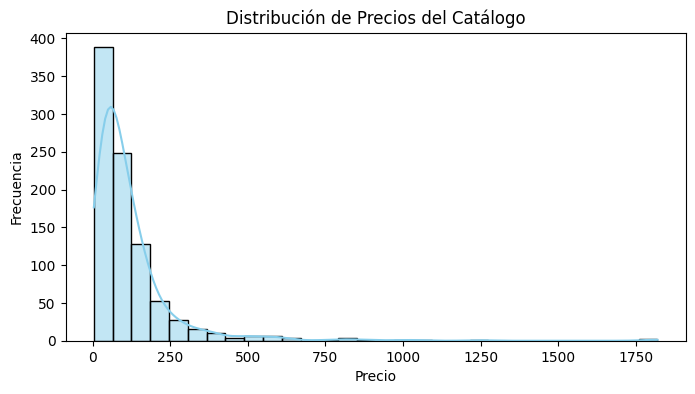

In [ ]:
# Configuramos el estilo del gráfico
plt.figure(figsize=(8, 4))
sns.histplot(df['price'], bins=30, kde=True, color='skyblue')

# Títulos y etiquetas
plt.title('Distribución de Precios del Catálogo')
plt.xlabel('Precio')
plt.ylabel('Frecuencia')

# Mostramos el gráfico
plt.show()

In [ ]:
# Guardamos el resultado final limpio en un nuevo archivo CSV
df.to_csv('catalogo_procesado_final.csv', index=False)

print("¡Archivo exportado con éxito como 'catalogo_procesado_final.csv'!")

¡Archivo exportado con éxito como 'catalogo_procesado_final.csv'!


LECTURA DEL TERCER DATAFRAME

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Proyecto3_Flujo-SQL-PY-DRR/Data/LIMPIEZA OLIST RAY.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             1000 non-null   object 
 1   product_id           1000 non-null   object 
 2   seller_id            1000 non-null   object 
 3   shipping_limit_date  1000 non-null   object 
 4   price                1000 non-null   float64
 5   freight_value        1000 non-null   float64
 6   cantidad             1000 non-null   int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 54.8+ KB


In [ ]:
# 1. Convertir fechas a datetime
if 'shipping_limit_date' in df.columns:
    df['shipping_limit_date'] = pd.to_datetime(df['shipping_limit_date'], errors='coerce')

In [ ]:
# Comprobamos si hay filas duplicadas
duplicados = df.duplicated().sum()
print(f"Número de filas duplicadas: {duplicados}")

Número de filas duplicadas: 0


In [ ]:
# Eliminamos las filas duplicadas
df = df.drop_duplicates()

# Comprobamos cuántas filas nos quedan ahora
print(f"Número de filas después de limpiar duplicados: {len(df)}")

Número de filas después de limpiar duplicados: 1000


In [ ]:
# 3. Analizar valores faltantes y documentar decisiones
val_faltantes = df.isnull().sum()
print("\nValores faltantes por columna:")
print(val_faltantes)
# Si existieran nulos en price o freight_value, podríamos imputar la mediana o eliminar la fila según criterio.


Valores faltantes por columna:
order_id               0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
cantidad               0
dtype: int64


In [ ]:
# 4. Normalizar cadenas (lower, trim)
str_cols = df.select_dtypes(include=['object', 'string']).columns
for col in str_cols:
    df[col] = df[col].astype(str).str.strip().str.lower()

In [ ]:
# 5. Corregir tipos numéricos
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['freight_value'] = pd.to_numeric(df['freight_value'], errors='coerce')
df['cantidad'] = df['cantidad'].astype(int)

In [ ]:
# 6. Detectar outliers (usando el método IQR sobre 'price' y 'freight_value')
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inferior = Q1 - 1.5 * IQR
    lim_superior = Q3 + 1.5 * IQR
    outliers = df[(df[columna] < lim_inferior) | (df[columna] > lim_superior)]
    return len(outliers)

print(f"\nOutliers detectados en 'price': {detectar_outliers_iqr(df, 'price')}")
print(f"Outliers detectados en 'freight_value': {detectar_outliers_iqr(df, 'freight_value')}")


Outliers detectados en 'price': 69
Outliers detectados en 'freight_value': 107


In [ ]:
# 7. Crear columnas derivadas útiles
# Ejemplo: Coste total de la línea de producto y desglose de fecha límite de envío
df['total_item_cost'] = (df['price'] + df['freight_value']) * df['cantidad']
df['shipping_year'] = df['shipping_limit_date'].dt.year
df['shipping_month'] = df['shipping_limit_date'].dt.month

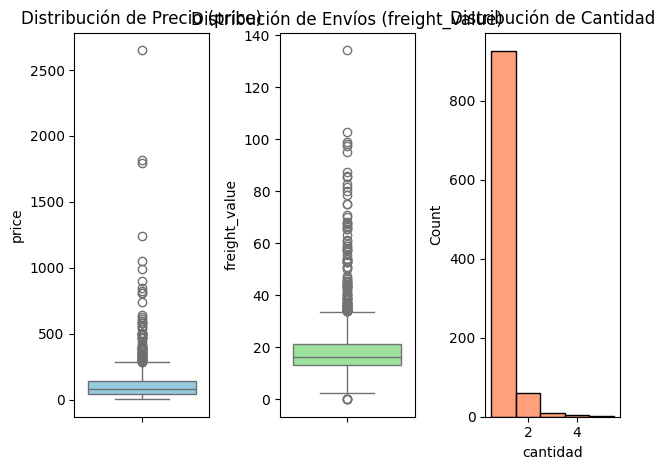

In [ ]:
# 8. Generar visualizaciones para validar la distribución de datos
# Distribución del precio
plt.subplot(1, 3, 1)
sns.boxplot(y=df['price'], color='skyblue')
plt.title('Distribución de Precio (price)')

# Distribución del coste de envío
plt.subplot(1, 3, 2)
sns.boxplot(y=df['freight_value'], color='lightgreen')
plt.title('Distribución de Envíos (freight_value)')

# Histograma de cantidad por pedido
plt.subplot(1, 3, 3)
sns.histplot(df['cantidad'], discrete=True, color='coral')
plt.title('Distribución de Cantidad')

plt.tight_layout()
plt.show()

In [ ]:
# Resumen estadístico de las columnas numéricas
df.describe()

,shipping_limit_date,price,freight_value,cantidad,total_item_cost,shipping_year,shipping_month
count,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2018-01-05 12:53:55.239000064,119.233840,19.849930,1.097000,148.648690,2017.548000,6.091000
min,2016-10-12 04:44:23,3.490000,0.000000,1.000000,15.570000,2016.000000,1.000000
25%,2017-09-19 18:04:02,41.987500,13.060000,1.000000,60.917500,2017.000000,3.000000
50%,2018-01-24 02:03:52,78.450000,16.240000,1.000000,103.720000,2018.000000,6.000000
75%,2018-05-05 11:03:28.500000,139.162500,21.335000,1.000000,167.962500,2018.000000,8.000000
max,2018-09-03 03:50:23,2649.990000,134.170000,5.000000,2784.160000,2018.000000,12.000000
std,NaN,167.119966,13.684364,0.384368,185.916857,0.501944,3.200463


In [ ]:
# 9. Exportar dataset final (No se sube al repo)
df.to_csv('limpieza_olist_ray_procesado.csv', index=False)